# The New York Times Spelling Bee, by the numbers

A theoretical look at the entire Spelling Bee puzzle space, anchored to 2,940+ real NYT
puzzles. The notebook ends with a German detour.

## 1. Setup and helpers

### 1.1 Upload the NYT history CSV

Locally, keep `nyt_spelling_bee_history_FULL.csv` (or the 365-day version) next to this
notebook; in Colab the cell below prompts for the upload.

In [ ]:
import os
CANDIDATES = ["nyt_spelling_bee_puzzles.csv"]
CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    print("No existing CSV found; aborting")
    exit(1)
print("loaded:", CSV_PATH)

loaded: nyt_spelling_bee_puzzles.csv


### 1.2 Packages and figure style

In [ ]:
import sys, subprocess
for pkg in ("wordfreq", "matplotlib", "numpy", "requests", "certifi", "scipy"):
    try:
        __import__(pkg)
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import importlib, requests
try:
    r = requests.get(
        "https://raw.githubusercontent.com/fabianrigterink/rigter-ink/"
        "main/notebooks/blogstyle.py", timeout=30)
    r.raise_for_status()
    with open("blogstyle.py", "w") as f:
        f.write(r.text)
except Exception as e:
    print("Couldn't fetch blogstyle.py!", e)
import blogstyle as B
importlib.reload(B); B.use()

import string, csv, datetime as dt, numpy as np, matplotlib.pyplot as plt
import wordfreq as wf
from collections import defaultdict
from matplotlib.patches import Patch, Polygon
PRIMARY, SECONDARY, HIGHLIGHT = B.PRIMARY, B.SECONDARY, B.HIGHLIGHT

### 1.3 Scoring engine

In [ ]:
import re

def word_points(word, ndistinct):
    n = len(word)
    base = 1 if n == 4 else n
    if ndistinct == 7:
        base += 7
    return base

def build(words, alphabet):
    bit = {ch: i for i, ch in enumerate(alphabet)}
    pat = re.compile("^[" + re.escape("".join(alphabet)) + "]+$")
    agg_pts = defaultdict(int); agg_cnt = defaultdict(int)
    longest_pangram = {}; kept = 0
    for w in words:
        if len(w) < 4 or not pat.match(w):
            continue
        s = set(w); nd = len(s)
        if nd > 7:
            continue
        m = 0
        for ch in s:
            m |= 1 << bit[ch]
        agg_pts[m] += word_points(w, nd); agg_cnt[m] += 1; kept += 1
        if nd == 7:
            lp = longest_pangram.get(m)
            if lp is None or len(w) > len(lp):
                longest_pangram[m] = w
    return dict(bit=bit, agg_pts=dict(agg_pts), agg_cnt=dict(agg_cnt),
                longest_pangram=longest_pangram, kept=kept)

def _submasks(m):
    sub = m
    while True:
        yield sub
        if sub == 0:
            break
        sub = (sub - 1) & m

def analyze(tab):
    agg_pts, agg_cnt = tab["agg_pts"], tab["agg_cnt"]
    pangram_sets = [m for m in agg_cnt if bin(m).count("1") == 7]
    puzzles = []
    for S in pangram_sets:
        present = [(m, agg_pts[m]) for m in _submasks(S) if m in agg_pts]
        score_by_center = defaultdict(int); words_by_center = defaultdict(int)
        for m, pts in present:
            mm = m
            while mm:
                c = mm & (-mm)
                score_by_center[c] += pts; words_by_center[c] += agg_cnt[m]; mm ^= c
        n_pan = agg_cnt[S]
        for c, sc in score_by_center.items():
            puzzles.append((sc, S, c, words_by_center[c], n_pan))
    return dict(puzzles=puzzles, pangram_sets=pangram_sets)

def mask_to_letters(m, bit):
    inv = {v: k for k, v in bit.items()}
    return "".join(sorted(inv[i] for i in range(len(bit)) if m & (1 << i)))

def bit_to_letter(c, bit):
    inv = {v: k for k, v in bit.items()}
    return inv[c.bit_length() - 1]

def sowpods_max(letters, center, tab):
    # theoretical Queen Bee for ANY (letters, center) — works for non-pangram sets too
    bit = tab["bit"]; agg = tab["agg_pts"]
    Sm = 0
    for ch in set(letters.lower()):
        if ch in bit: Sm |= 1 << bit[ch]
    cbit = 1 << bit[center.lower()]
    total = 0; sub = Sm
    while True:
        if (sub & cbit) and sub in agg:
            total += agg[sub]
        if sub == 0:
            break
        sub = (sub - 1) & Sm
    return total

def solve_puzzle(letters, center, words):
    # Return the valid word list for a puzzle (any list of pre-filtered words).
    L = set(c.lower() for c in letters); c = center.lower()
    return [w for w in words if len(w) >= 4 and c in w and set(w).issubset(L)]

def print_solution(label, letters, center, words):
    ws = sorted(solve_puzzle(letters, center, words),
                key=lambda w: (-word_points(w, len(set(w))), w))
    total = sum(word_points(w, len(set(w))) for w in ws)
    print(f"\n{label} — {letters.upper()}/{center.upper()}: "
          f"{len(ws)} word{'s' if len(ws) != 1 else ''}, {total} theoretical pts")
    for w in ws:
        marker = " (pangram)" if len(set(w)) == 7 else ""
        print(f"  {word_points(w, len(set(w))):>3}  {w.upper()}{marker}")

### 1.4 Word lists (SOWPODS for English, hippler for German)

In [ ]:
ENGLISH_URL = ("https://raw.githubusercontent.com/jesstess/Scrabble/"
               "refs/heads/master/scrabble/sowpods.txt")
GERMAN_URL  = ("https://raw.githubusercontent.com/hippler/german-wordlist/"
               "refs/heads/master/words.txt")

def _fetch(url):
    try:    return requests.get(url, timeout=90).text.split()
    except Exception:
        return urllib.request.urlopen(url, timeout=90).read().decode("utf-8", "replace").split()

EN_words = [w.lower() for w in _fetch(ENGLISH_URL) if len(w) >= 4 and "-" not in w]
DE_words = [w.lower() for w in _fetch(GERMAN_URL)  if len(w) >= 4 and "-" not in w]

ALPHA_EN = string.ascii_lowercase
ALPHA_DE = "abcdefghijklmnopqrstuvwxyzäöü"     # hippler list contains no ß

tab_en = build(EN_words, ALPHA_EN); res_en = analyze(tab_en); bit_en = tab_en["bit"]
tab_de = build(DE_words, ALPHA_DE); res_de = analyze(tab_de); bit_de = tab_de["bit"]

scores_en = np.array([p[0] for p in res_en["puzzles"]])
scores_de = np.array([p[0] for p in res_de["puzzles"]])
print(f"English (SOWPODS) : {tab_en['kept']:,} words -> {len(res_en['puzzles']):,} puzzles")
print(f"German  (hippler) : {tab_de['kept']:,} words -> {len(res_de['puzzles']):,} puzzles")

English (SOWPODS) : 145,923 words -> 142,261 puzzles
German  (hippler) : 235,560 words -> 174,909 puzzles


### 1.5 Draw a puzzle (NYT-style honeycomb)

In [ ]:
NYT_YELLOW, TILE_GRAY = "#F7DA21", "#E8E8E8"

def _hexagon(cx, cy, r):
    a = np.deg2rad([0, 60, 120, 180, 240, 300])
    return np.column_stack([cx + r * np.cos(a), cy + r * np.sin(a)])

def draw_puzzle(letters, center, ax=None, title=None, subtitle=None):
    letters = [c.lower() for c in letters]; center = center.lower()
    outer = [c for c in letters if c != center]
    assert len(letters) == 7 and len(set(letters)) == 7 and center in letters
    r = 1.0; h = np.sqrt(3) * r
    ring = [(0, h), (1.5*r, h/2), (1.5*r, -h/2), (0, -h), (-1.5*r, -h/2), (-1.5*r, h/2)]
    own_ax = ax is None
    if own_ax:
        _, ax = plt.subplots(figsize=(3.6, 4.6))
    for (cx, cy), ch in zip(ring, outer):
        ax.add_patch(Polygon(_hexagon(cx, cy, 0.93), closed=True,
                             facecolor=TILE_GRAY, edgecolor="white", lw=3))
        ax.text(cx, cy, ch.upper(), ha="center", va="center",
                fontsize=20, fontweight="bold", color=B.INK)
    ax.add_patch(Polygon(_hexagon(0, 0, 0.93), closed=True,
                         facecolor=NYT_YELLOW, edgecolor="white", lw=3))
    ax.text(0, 0, center.upper(), ha="center", va="center",
            fontsize=20, fontweight="bold", color=B.INK)
    ax.set_xlim(-2.7, 2.7); ax.set_ylim(-3.6, 3.6)
    ax.set_aspect("equal"); ax.axis("off")
    # title above and subtitle below, symmetric around the puzzle
    if title:
        ax.text(0, 3.1, title, ha="center", va="top",
                fontsize=13, fontweight="bold", color=B.INK)
    if subtitle:
        ax.text(0, -3.1, subtitle, ha="center", va="top",
                fontsize=10, color=B.INK_MUTED)
    return ax

### 1.6 Load NYT history and define rank-tier helpers

In [ ]:
TIERS = [("Beginner", 0), ("Good Start", 2), ("Moving Up", 5), ("Good", 8),
         ("Solid", 15), ("Nice", 25), ("Great", 40), ("Amazing", 50),
         ("Genius", 70), ("Queen Bee", 100)]
half_up = lambda pct, mx: (pct * mx + 50) // 100

nyt_hist = list(csv.DictReader(open(CSV_PATH)))
nyt_max  = np.array([int(r["max_score"]) for r in nyt_hist])
nyt_pang = np.array([int(r["pangrams"])  for r in nyt_hist])
print(f"NYT history: {len(nyt_hist):,} puzzles, "
      f"dates {nyt_hist[0]['date']} -> {nyt_hist[-1]['date']}, "
      f"max-score {nyt_max.min()}-{nyt_max.max()}")

NYT history: 2,944 puzzles, dates 2018-05-09 -> 2026-05-30, max-score 47-537


## 2. Derive `NYT_FACTOR` — how NYT's actual score relates to the theoretical max

For each real NYT puzzle, score it with our SOWPODS engine; the ratio's mean is the
factor we use to translate any theoretical max into an estimated real NYT Queen Bee.

NYT/theoretical: mean=40.6%  median=39.8%  range 15-81%   ->   NYT_FACTOR = 0.406
  wrote figures/01_nyt_factor.png


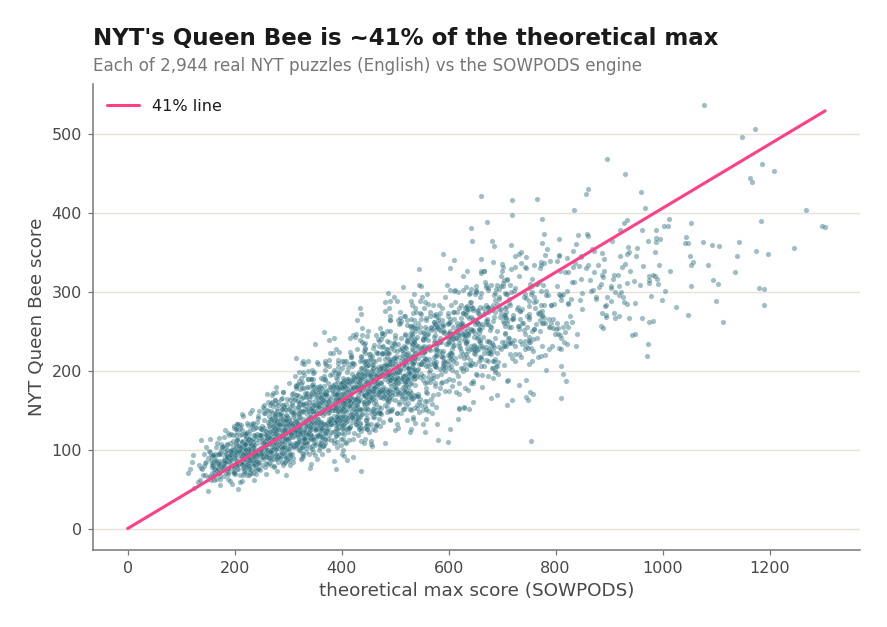

In [ ]:
ours_th = np.array([sowpods_max(r["letters"], r["center"], tab_en) for r in nyt_hist])
ratio   = nyt_max / ours_th * 100
NYT_FACTOR = float(ratio.mean() / 100)
nyt_est = lambda s: int(round(NYT_FACTOR * s))
print(f"NYT/theoretical: mean={ratio.mean():.1f}%  median={np.median(ratio):.1f}%  "
      f"range {ratio.min():.0f}-{ratio.max():.0f}%   ->   NYT_FACTOR = {NYT_FACTOR:.3f}")

fig, ax = plt.subplots()
ax.scatter(ours_th, nyt_max, s=12, color=PRIMARY, alpha=0.45, edgecolor=B.SURFACE, linewidth=0.2)
xx = np.array([0, ours_th.max()])
ax.plot(xx, NYT_FACTOR * xx, color=HIGHLIGHT, lw=2, label=f"{NYT_FACTOR*100:.0f}% line")
ax.set_xlabel("theoretical max score (SOWPODS)")
ax.set_ylabel("NYT Queen Bee score")
ax.legend()
B.title(ax, f"NYT's Queen Bee is ~{NYT_FACTOR*100:.0f}% of the theoretical max",
        f"Each of {len(nyt_hist):,} real NYT puzzles (English) vs the SOWPODS engine")
B.show(fig, title="nyt factor")

## 3. Distribution of max scores

A puzzle's max score is the sum of every valid word's points. In the theoretical SOWPODS
space we call it the *theoretical max*; for a real NYT puzzle it's the *NYT Queen Bee
score*. Plotting that distribution shows what kind of puzzles the space contains and
where the NYT actually picks from. Two views per population: full range, then a zoom to
the bulk (0 → p95).

In [ ]:
def score_hist(ax, scores, xlim, color, bins=60):
    # Plain histogram of Queen Bee (max) scores.
    ax.hist(scores, bins=bins, range=xlim, color=color,
            edgecolor=B.SURFACE, linewidth=0.25)
    ax.set_xlim(xlim)
    ax.set_ylabel("number of puzzles")

HIST_ALPHA = 0.6   # single transparency for every two-hue histogram

def hist_compare(ax, populations, xlim, bins=70, alpha=HIST_ALPHA):
    # Overlay of max-score distributions across two populations; y-axis in % of puzzles.
    for label, (values, color) in populations.items():
        v = np.asarray(values)
        w = np.full(v.shape, 100.0 / len(v))
        ax.hist(v, bins=bins, range=xlim, weights=w,
                color=color, alpha=alpha, label=label,
                edgecolor=B.SURFACE, linewidth=0.2)
    ax.set_xlim(xlim)
    ax.set_ylabel("% of puzzles")
    B.pct(ax, "y", decimals=0, xmax=100)
    ax.legend(loc="upper right", frameon=False)

### 3.1 All theoretical puzzles (English SOWPODS)

  wrote figures/02_rank_distribution_theoretical_full.png


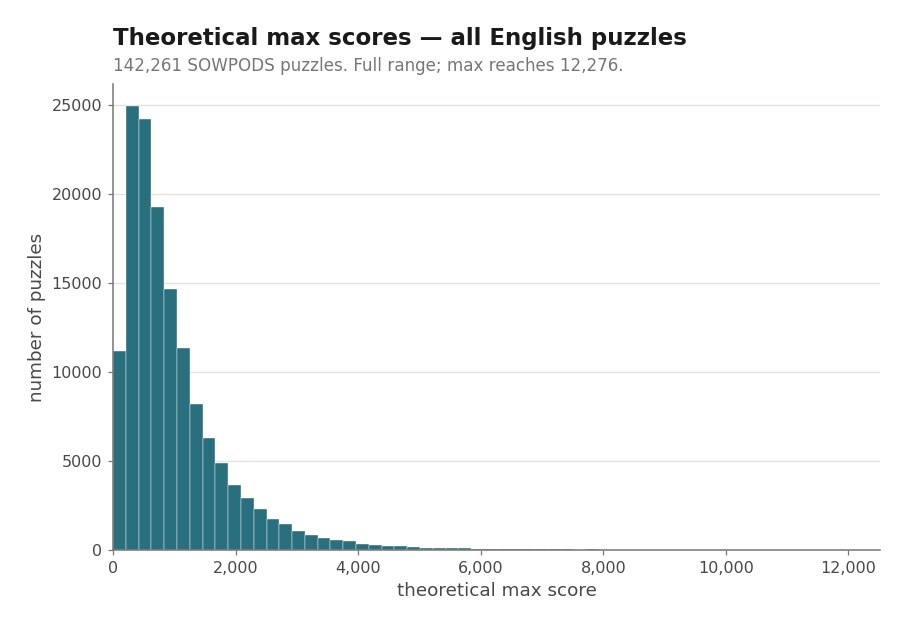

  wrote figures/03_rank_distribution_theoretical_zoom.png


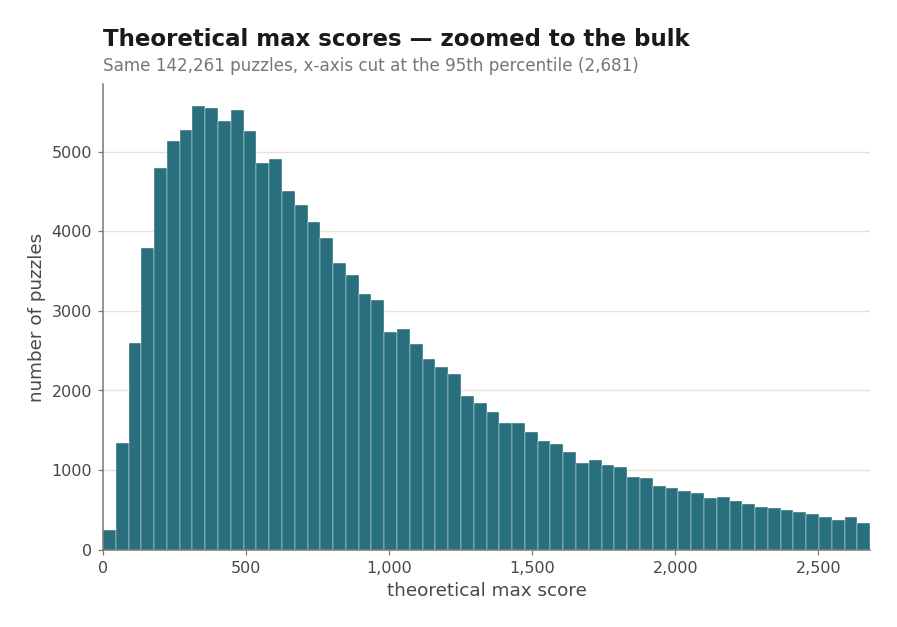

In [ ]:
xmax_full = int(scores_en.max() * 1.02)
xmax_zoom = int(np.percentile(scores_en, 95))

fig, ax = plt.subplots(figsize=(9, 5.5))
score_hist(ax, scores_en, xlim=(0, xmax_full), color=PRIMARY)
ax.set_xlabel("theoretical max score"); B.thousands(ax, "x")
B.title(ax, "Theoretical max scores — all English puzzles",
        f"{len(scores_en):,} SOWPODS puzzles. Full range; max reaches {scores_en.max():,}.")
B.show(fig, title="rank distribution theoretical full")

fig, ax = plt.subplots(figsize=(9, 5.5))
score_hist(ax, scores_en, xlim=(0, xmax_zoom), color=PRIMARY)
ax.set_xlabel("theoretical max score"); B.thousands(ax, "x")
B.title(ax, "Theoretical max scores — zoomed to the bulk",
        f"Same {len(scores_en):,} puzzles, x-axis cut at the 95th percentile ({xmax_zoom:,})")
B.show(fig, title="rank distribution theoretical zoom")

### 3.2 Only past NYT puzzles

  wrote figures/04_rank_distribution_nyt_full.png


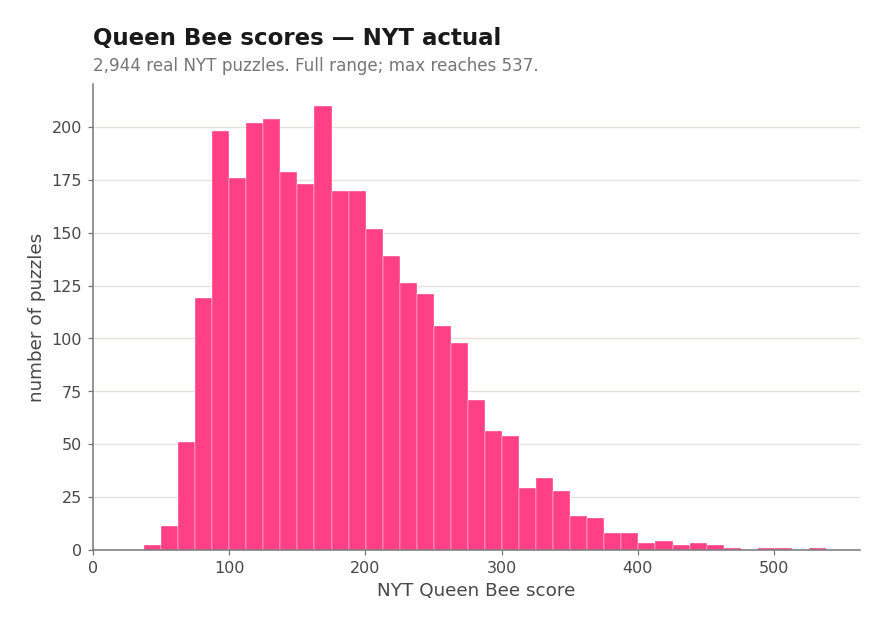

  wrote figures/05_rank_distribution_nyt_zoom.png


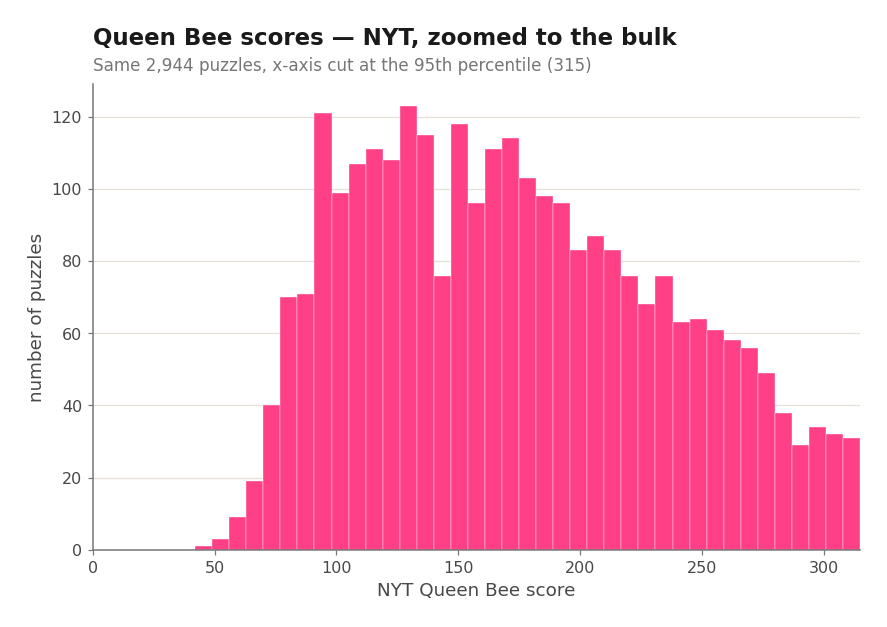

In [ ]:
xmax_nyt_full = int(nyt_max.max() * 1.05)
xmax_nyt_zoom = int(np.percentile(nyt_max, 95))

fig, ax = plt.subplots(figsize=(9, 5.5))
score_hist(ax, nyt_max, xlim=(0, xmax_nyt_full), color=HIGHLIGHT, bins=45)
ax.set_xlabel("NYT Queen Bee score"); B.thousands(ax, "x")
B.title(ax, "Queen Bee scores — NYT actual",
        f"{len(nyt_max):,} real NYT puzzles. Full range; max reaches {nyt_max.max():,}.")
B.show(fig, title="rank distribution nyt full")

fig, ax = plt.subplots(figsize=(9, 5.5))
score_hist(ax, nyt_max, xlim=(0, xmax_nyt_zoom), color=HIGHLIGHT, bins=45)
ax.set_xlabel("NYT Queen Bee score"); B.thousands(ax, "x")
B.title(ax, "Queen Bee scores — NYT, zoomed to the bulk",
        f"Same {len(nyt_max):,} puzzles, x-axis cut at the 95th percentile ({xmax_nyt_zoom:,})")
B.show(fig, title="rank distribution nyt zoom")

### 3.3 Overlay — where the NYT is fishing on the theoretical scale

Both populations plotted on the theoretical SOWPODS scale: the NYT Queen Bee scores are
divided by `NYT_FACTOR` to give each NYT puzzle its estimated theoretical max.

  wrote figures/06_rank_distribution_overlay_full.png


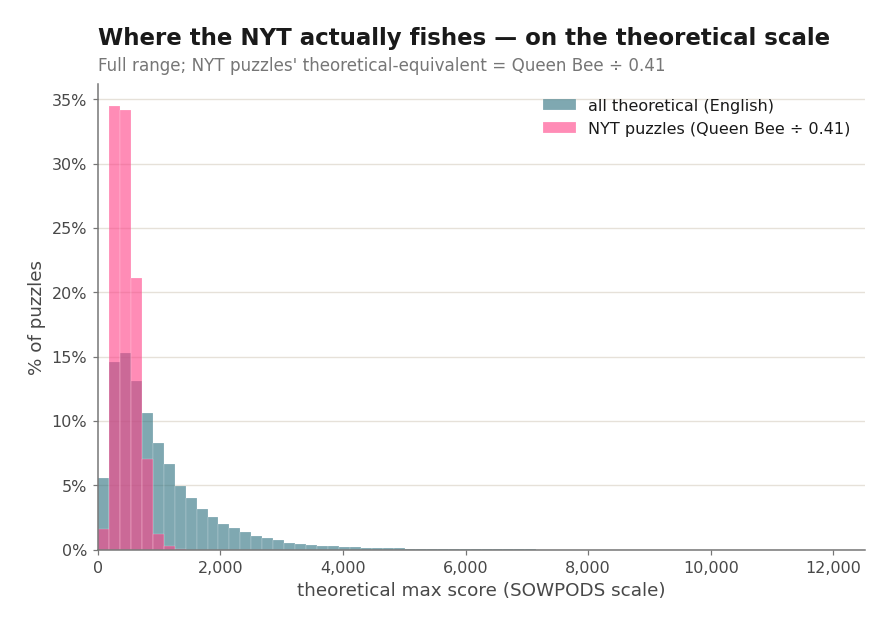

  wrote figures/07_rank_distribution_overlay_zoom.png


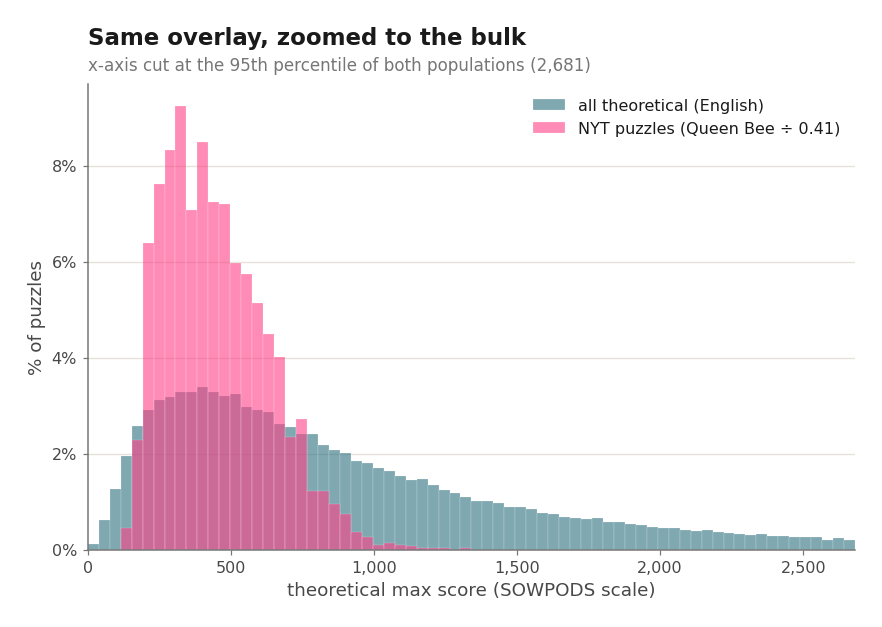

In [ ]:
nyt_rescaled = nyt_max / NYT_FACTOR
xmax_o_full = int(max(scores_en.max(), nyt_rescaled.max()) * 1.02)
xmax_o_zoom = int(max(np.percentile(scores_en, 95), np.percentile(nyt_rescaled, 95)))

pops = {"all theoretical (English)": (scores_en, PRIMARY),
        f"NYT puzzles (Queen Bee ÷ {NYT_FACTOR:.2f})": (nyt_rescaled, HIGHLIGHT)}

fig, ax = plt.subplots(figsize=(9, 5.5))
hist_compare(ax, pops, xlim=(0, xmax_o_full))
ax.set_xlabel("theoretical max score (SOWPODS scale)"); B.thousands(ax, "x")
B.title(ax, "Where the NYT actually fishes — on the theoretical scale",
        f"Full range; NYT puzzles' theoretical-equivalent = Queen Bee ÷ {NYT_FACTOR:.2f}")
B.show(fig, title="rank distribution overlay full")

fig, ax = plt.subplots(figsize=(9, 5.5))
hist_compare(ax, pops, xlim=(0, xmax_o_zoom))
ax.set_xlabel("theoretical max score (SOWPODS scale)"); B.thousands(ax, "x")
B.title(ax, "Same overlay, zoomed to the bulk",
        f"x-axis cut at the 95th percentile of both populations ({xmax_o_zoom:,})")
B.show(fig, title="rank distribution overlay zoom")

## 4. Extremes (English)

### 4.1 Highest-scoring words in the entire dictionary (top 10)

In [ ]:
# longest pangram per 7-distinct-letter signature; score = length + 7
top = sorted(tab_en["longest_pangram"].values(), key=len, reverse=True)[:10]
print(f"{'#':>2}  {'word':<22} {'length':>6}  {'points':>6}")
for i, w in enumerate(top, 1):
    print(f"{i:>2}  {w:<22} {len(w):>6}  {len(w)+7:>6}")

 #  word                   length  points
 1  accessarinesses            15      22
 2  incandescencies            15      22
 3  incessantnesses            15      22
 4  associationists            15      22
 5  dreadlessnesses            15      22
 6  aggregatenesses            15      22
 7  antagonisations            15      22
 8  antinationalist            15      22
 9  inalienableness            15      22
10  essentialnesses            15      22


### 4.2 Hardest- and richest-scoring puzzles — theoretical and NYT

theoretical RICHEST: AEINRST center E -> 12,276 pts theoretical (~4,986 NYT est.), 1,650 words, 129 pangrams
theoretical HARDEST: CINOPRX center X -> 14 pts theoretical (~6 NYT est.), 1 words, 1 pangrams
NYT RICHEST       : CEINOTV center I (2021-01-22) -> 537 NYT Queen Bee, 75 words, 7 pangrams
NYT HARDEST       : FIMORTY center F (2023-03-27) -> 47 NYT Queen Bee, 16 words, 1 pangrams
  wrote figures/08_extreme_puzzles.png


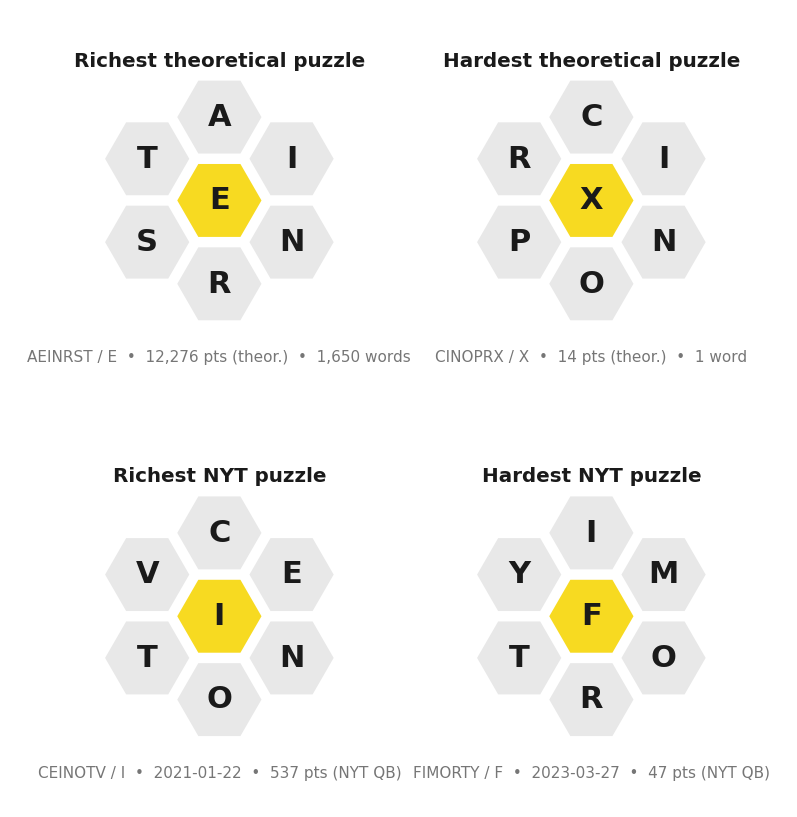


Hardest theoretical (English) — CINOPRX/X: 1 word, 14 theoretical pts
   14  PRINCOX (pangram)

Hardest NYT puzzle (solved with SOWPODS) — FIMORTY/F: 41 words, 150 theoretical pts
   14  MORTIFY (pangram)
    9  MITRIFORM
    8  ROTIFORM
    7  FOOTROT
    7  FORTIFY
    7  TORRIFY
    7  TRIFORM
    6  FORRIT
    5  FIFTY
    5  FIRRY
    5  FOOTY
    5  FORTY
    5  FRITT
    5  FRORY
    5  MIFFY
    5  MIFTY
    5  MOTIF
    5  RIFTY
    5  ROOFY
    5  TOFFY
    5  TRIFF
    1  FIFI
    1  FIRM
    1  FITT
    1  FOOT
    1  FORM
    1  FORT
    1  FRIT
    1  FROM
    1  IFFY
    1  MIFF
    1  MOFO
    1  OOFY
    1  RIFF
    1  RIFT
    1  ROOF
    1  TIFF
    1  TIFT
    1  TOFF
    1  TOFT
    1  YOOF


In [ ]:
# theoretical extremes (the engine already enumerated valid puzzles)
hi_th, lo_th = max(res_en["puzzles"]), min(res_en["puzzles"])
def lstr(rec, t):
    sc, S, c, nw, npan = rec
    return mask_to_letters(S, t["bit"]).upper(), bit_to_letter(c, t["bit"]).upper(), sc, nw, npan
hi_t = lstr(hi_th, tab_en); lo_t = lstr(lo_th, tab_en)

# NYT extremes (from the CSV)
hi_n = max(nyt_hist, key=lambda r: int(r["max_score"]))
lo_n = min(nyt_hist, key=lambda r: int(r["max_score"]))

def fmt_th(name, L, C, sc, nw, npan):
    return (f"{name}: {L} center {C} -> {sc:,} pts theoretical "
            f"(~{nyt_est(sc):,} NYT est.), {nw:,} words, {npan} pangrams")
def fmt_nyt(name, r):
    return (f"{name}: {r['letters']} center {r['center']} ({r['date']}) -> "
            f"{r['max_score']} NYT Queen Bee, {r['words']} words, {r['pangrams']} pangrams")

print(fmt_th("theoretical RICHEST", *hi_t))
print(fmt_th("theoretical HARDEST", *lo_t))
print(fmt_nyt("NYT RICHEST       ", hi_n))
print(fmt_nyt("NYT HARDEST       ", lo_n))

fig, axes = plt.subplots(2, 2, figsize=(8, 9))
draw_puzzle(hi_t[0], hi_t[1], ax=axes[0][0],
            title="Richest theoretical puzzle",
            subtitle=f"{hi_t[0]} / {hi_t[1]}  •  {hi_t[2]:,} pts (theor.)  •  {hi_t[3]:,} words")
draw_puzzle(lo_t[0], lo_t[1], ax=axes[0][1],
            title="Hardest theoretical puzzle",
            subtitle=f"{lo_t[0]} / {lo_t[1]}  •  {lo_t[2]} pts (theor.)  •  {lo_t[3]} word")
draw_puzzle(hi_n["letters"], hi_n["center"], ax=axes[1][0],
            title="Richest NYT puzzle",
            subtitle=f"{hi_n['letters']} / {hi_n['center']}  •  {hi_n['date']}  •  {hi_n['max_score']} pts (NYT QB)")
draw_puzzle(lo_n["letters"], lo_n["center"], ax=axes[1][1],
            title="Hardest NYT puzzle",
            subtitle=f"{lo_n['letters']} / {lo_n['center']}  •  {lo_n['date']}  •  {lo_n['max_score']} pts (NYT QB)")
B.show(fig, title="extreme puzzles")

# Full solutions for the hardest puzzles (SOWPODS for both — the NYT word list is private).
print_solution("Hardest theoretical (English)", lo_t[0], lo_t[1], EN_words)
print_solution("Hardest NYT puzzle (solved with SOWPODS)",
               lo_n["letters"], lo_n["center"], EN_words)

### 4.3 Number of pangrams per puzzle — theoretical vs NYT

  wrote figures/09_pangram_count_distribution.png


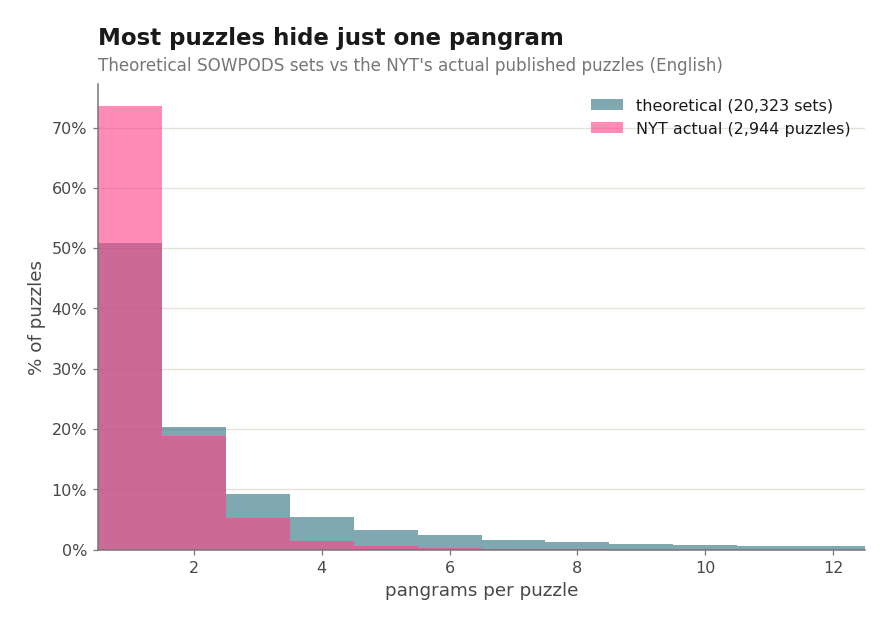

In [ ]:
# theoretical: pangrams per pangram-set (i.e. per puzzle's 7-letter set)
set_pan = {}
for sc, S, c, nw, npan in res_en["puzzles"]:
    set_pan[S] = npan
pv_th = np.array(list(set_pan.values()))

fig, ax = plt.subplots()
xmax = int(max(pv_th.max(), nyt_pang.max())) + 1
bins = np.arange(1, xmax+2) - 0.5
w_th  = np.full(pv_th.shape,    100.0 / len(pv_th))
w_nyt = np.full(nyt_pang.shape, 100.0 / len(nyt_pang))
ax.hist(pv_th,    bins=bins, weights=w_th,  color=PRIMARY,   alpha=HIST_ALPHA, label=f"theoretical ({len(pv_th):,} sets)")
ax.hist(nyt_pang, bins=bins, weights=w_nyt, color=HIGHLIGHT, alpha=HIST_ALPHA, label=f"NYT actual ({len(nyt_pang):,} puzzles)")
ax.set_xlim(0.5, 12.5)
ax.set_xlabel("pangrams per puzzle"); ax.set_ylabel("% of puzzles")
B.pct(ax, "y", decimals=0, xmax=100)
ax.legend()
B.title(ax, "Most puzzles hide just one pangram",
        "Theoretical SOWPODS sets vs the NYT's actual published puzzles (English)")
B.show(fig, title="pangram count distribution")

## 5. Center letter

### 5.1 Mean puzzle score by center letter — theoretical vs NYT

  wrote figures/10_centre_letter_english.png


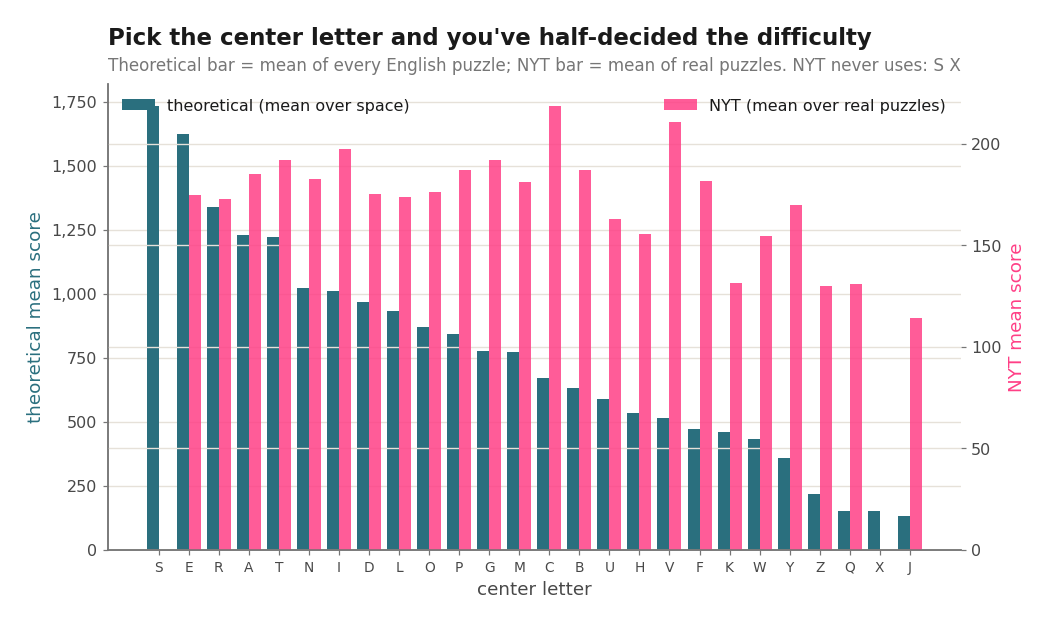

In [ ]:
# theoretical mean score per center letter
th_by_center = defaultdict(list)
for sc, S, c, nw, npan in res_en["puzzles"]:
    th_by_center[bit_to_letter(c, bit_en)].append(sc)
th_mean = {ch.upper(): np.mean(v) for ch, v in th_by_center.items()}

# NYT mean by center letter
ny_by_center = defaultdict(list)
for r in nyt_hist:
    ny_by_center[r["center"]].append(int(r["max_score"]))
ny_mean = {ch: np.mean(v) for ch, v in ny_by_center.items()}
ny_count = {ch: len(v) for ch, v in ny_by_center.items()}

letters_sorted = sorted(th_mean, key=lambda k: -th_mean[k])
x = np.arange(len(letters_sorted)); w = 0.4
fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.bar(x - w/2, [th_mean[l] for l in letters_sorted], w, color=PRIMARY, label="theoretical (mean over space)")
ax1.set_ylabel("theoretical mean score", color=PRIMARY); B.thousands(ax1, "y")
ax1.set_xticks(x); ax1.set_xticklabels(letters_sorted, fontsize=9)
ax1.set_xlabel("center letter")
ax2 = ax1.twinx()
ax2.bar(x + w/2, [ny_mean.get(l, 0) for l in letters_sorted], w, color=HIGHLIGHT, alpha=0.85,
        label="NYT (mean over real puzzles)")
ax2.set_ylabel("NYT mean score", color=HIGHLIGHT)
# missing letters in NYT (never used as centre)
missing = [l for l in letters_sorted if l not in ny_mean]
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
B.title(ax1, "Pick the center letter and you've half-decided the difficulty",
        f"Theoretical bar = mean of every English puzzle; NYT bar = mean of real puzzles. "
        f"NYT never uses: {' '.join(missing) if missing else 'none'}")
B.show(fig, title="centre letter english")

### 5.2 Contains S vs does not — theoretical only (the NYT never uses S)

with-S puzzles: mean=1343  max=12,276
no-S  puzzles : mean=669  max=5,239
NYT puzzles containing S: 3 of 2,944
  wrote figures/11_s_rule_english.png


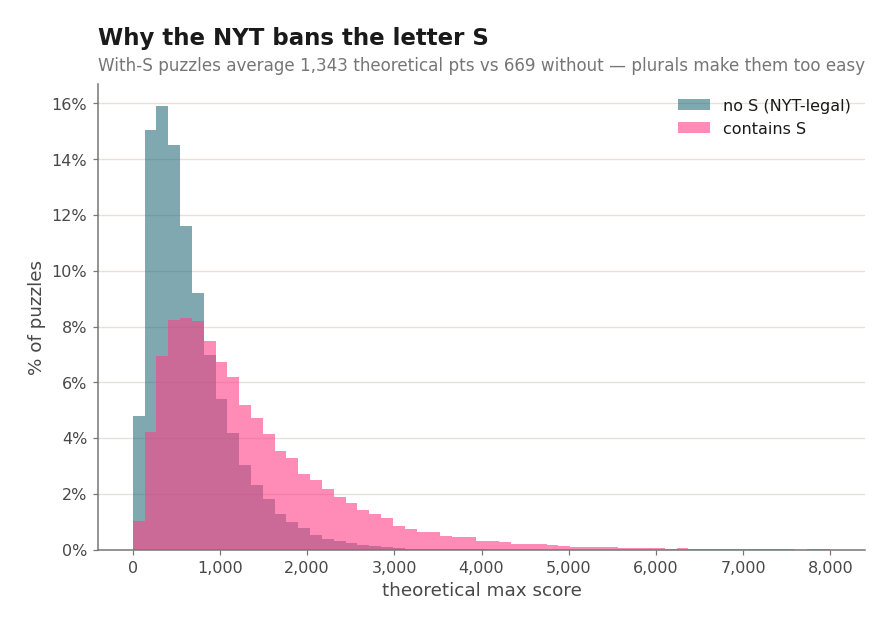

In [ ]:
sbit = 1 << bit_en["s"]
withs = np.array([p[0] for p in res_en["puzzles"] if p[1] & sbit])
nos   = np.array([p[0] for p in res_en["puzzles"] if not p[1] & sbit])
print(f"with-S puzzles: mean={withs.mean():.0f}  max={withs.max():,}")
print(f"no-S  puzzles : mean={nos.mean():.0f}  max={nos.max():,}")
print(f"NYT puzzles containing S: {sum(1 for r in nyt_hist if 'S' in r['letters'])} of {len(nyt_hist):,}")

fig, ax = plt.subplots()
bins = np.linspace(0, 8000, 60)
w_nos   = np.full(nos.shape,   100.0 / len(nos))
w_withs = np.full(withs.shape, 100.0 / len(withs))
ax.hist(nos,   bins=bins, weights=w_nos,   color=PRIMARY,   alpha=HIST_ALPHA, label="no S (NYT-legal)")
ax.hist(withs, bins=bins, weights=w_withs, color=HIGHLIGHT, alpha=HIST_ALPHA, label="contains S")
ax.set_xlabel("theoretical max score"); ax.set_ylabel("% of puzzles")
B.thousands(ax, "x"); B.pct(ax, "y", decimals=0, xmax=100); ax.legend()
B.title(ax, "Why the NYT bans the letter S",
        f"With-S puzzles average {withs.mean():,.0f} theoretical pts vs {nos.mean():,.0f} without — plurals make them too easy")
B.show(fig, title="s rule english")

## 6. Switch to German

All analyses below use the [hippler German word list](https://github.com/hippler/german-wordlist).
Umlauts **ä ö ü** are treated as distinct letters; there is no German NYT Spelling Bee,
so this section is theoretical-only.

### 6.1 Distribution of scores — German with English overlaid

  wrote figures/12_distribution_german_v_english_full.png


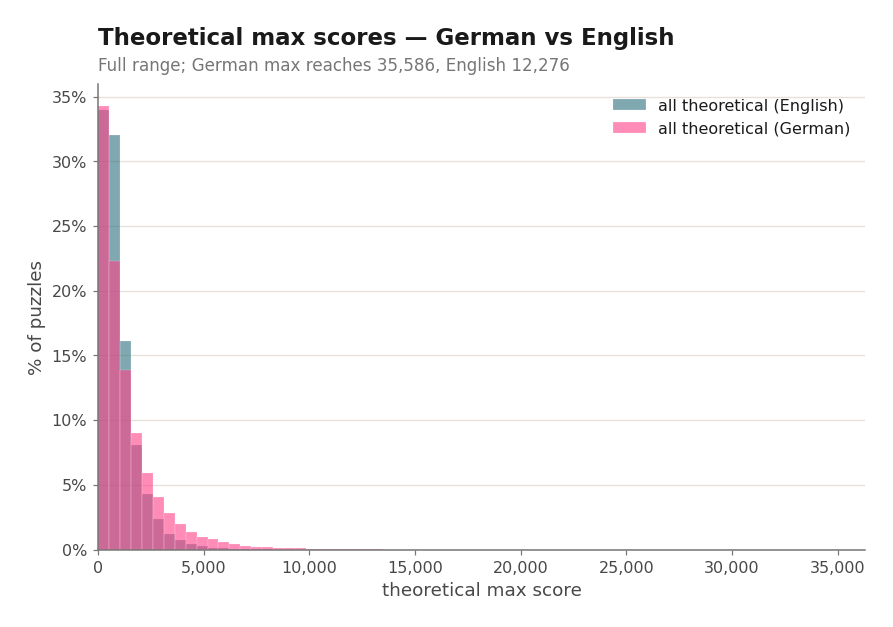

  wrote figures/13_distribution_german_v_english_zoom.png


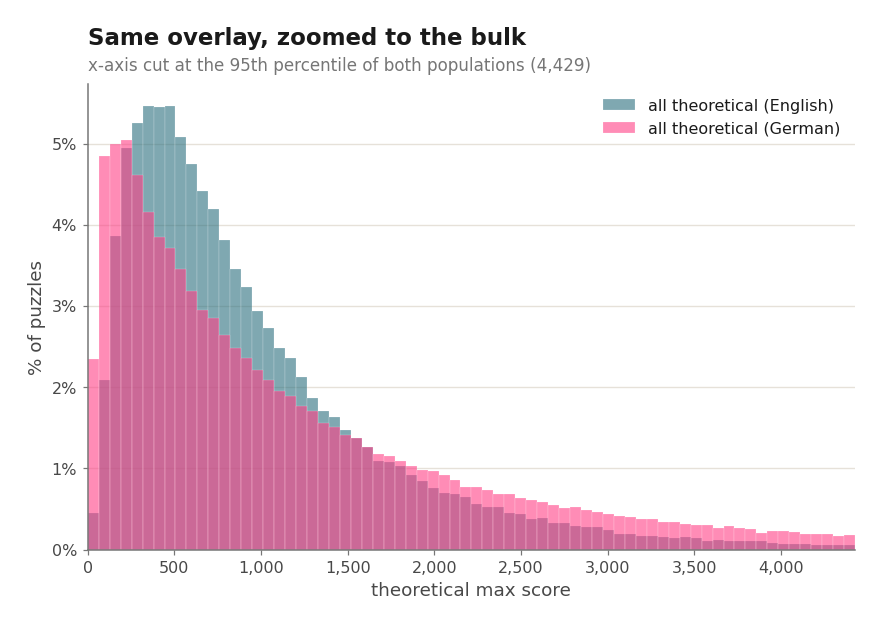

In [ ]:
pops_de = {"all theoretical (English)": (scores_en, PRIMARY),
           "all theoretical (German)":  (scores_de, HIGHLIGHT)}
xmax_de_full = int(max(scores_en.max(), scores_de.max()) * 1.02)
xmax_de_zoom = int(max(np.percentile(scores_en, 95), np.percentile(scores_de, 95)))

fig, ax = plt.subplots(figsize=(9, 5.5))
hist_compare(ax, pops_de, xlim=(0, xmax_de_full))
ax.set_xlabel("theoretical max score"); B.thousands(ax, "x")
B.title(ax, "Theoretical max scores — German vs English",
        f"Full range; German max reaches {scores_de.max():,}, English {scores_en.max():,}")
B.show(fig, title="distribution german v english full")

fig, ax = plt.subplots(figsize=(9, 5.5))
hist_compare(ax, pops_de, xlim=(0, xmax_de_zoom))
ax.set_xlabel("theoretical max score"); B.thousands(ax, "x")
B.title(ax, "Same overlay, zoomed to the bulk",
        f"x-axis cut at the 95th percentile of both populations ({xmax_de_zoom:,})")
B.show(fig, title="distribution german v english zoom")

### 6.2 Extremes (German)

#### 6.2.1 Highest-scoring words (top 10)

In [ ]:
top_de = sorted(tab_de["longest_pangram"].values(), key=len, reverse=True)[:10]
print(f"{'#':>2}  {'word':<26} {'length':>6}  {'points':>6}")
for i, w in enumerate(top_de, 1):
    print(f"{i:>2}  {w:<26} {len(w):>6}  {len(w)+7:>6}")

 #  word                       length  points
 1  interessensorientierten        23      30
 2  regierungsgegnerinnen          21      28
 3  gesinnungsgenossinnen          21      28
 4  desinteressiertesten           20      27
 5  geringverdienerinnen           20      27
 6  stressresistentestem           20      27
 7  schreckensherrschern           20      27
 8  batteriebetriebenen            19      26
 9  allerseelenablasses            19      26
10  aneinanderreihenden            19      26


#### 6.2.2 Hardest and richest German puzzles (theoretical)

German RICHEST: EGINRST center E -> 35,586 pts theoretical (~14,454 NYT est.), 3,993 words, 322 pangrams
German HARDEST: ABCFLOX center X -> 14 pts theoretical (~6 NYT est.), 1 words, 1 pangrams
  wrote figures/14_extreme_puzzles_german.png


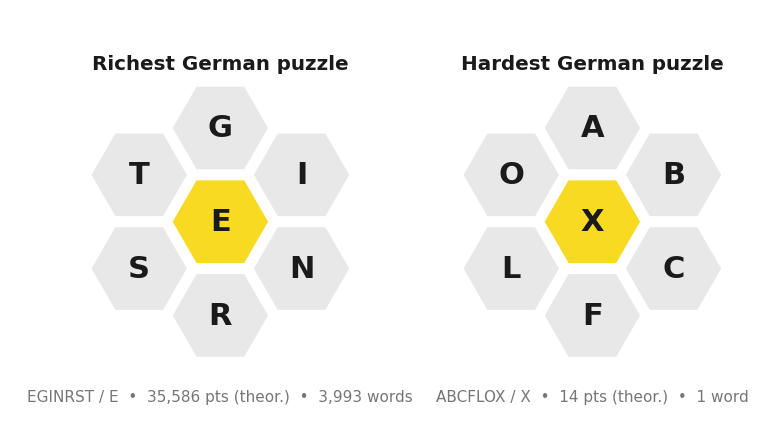


Hardest theoretical (German) — ABCFLOX/X: 1 word, 14 theoretical pts
   14  BOXCALF (pangram)


In [ ]:
hi_d, lo_d = max(res_de["puzzles"]), min(res_de["puzzles"])
hi_dt = lstr(hi_d, tab_de); lo_dt = lstr(lo_d, tab_de)
print(fmt_th("German RICHEST", *hi_dt))
print(fmt_th("German HARDEST", *lo_dt))

fig, axes = plt.subplots(1, 2, figsize=(8, 4.6))
draw_puzzle(hi_dt[0], hi_dt[1], ax=axes[0],
            title="Richest German puzzle",
            subtitle=f"{hi_dt[0]} / {hi_dt[1]}  •  {hi_dt[2]:,} pts (theor.)  •  {hi_dt[3]:,} words")
draw_puzzle(lo_dt[0], lo_dt[1], ax=axes[1],
            title="Hardest German puzzle",
            subtitle=f"{lo_dt[0]} / {lo_dt[1]}  •  {lo_dt[2]} pts (theor.)  •  {lo_dt[3]} word")
B.show(fig, title="extreme puzzles german")

# Full solution for the hardest German puzzle.
print_solution("Hardest theoretical (German)", lo_dt[0], lo_dt[1], DE_words)

#### 6.2.3 Pangrams per puzzle (German)

  wrote figures/15_pangram_count_german.png


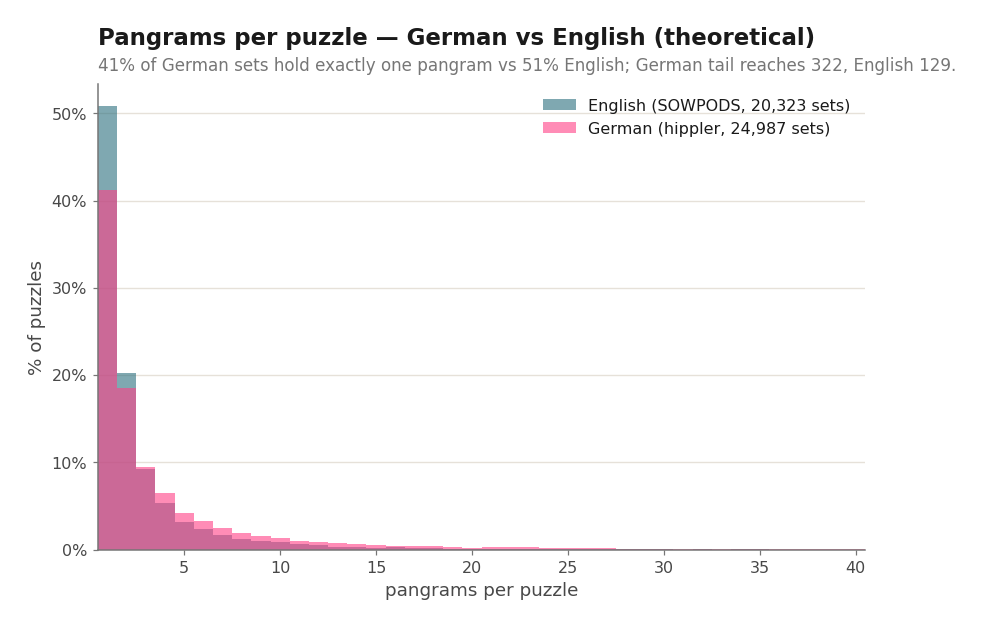

In [ ]:
set_pan_de = {}
for sc, S, c, nw, npan in res_de["puzzles"]:
    set_pan_de[S] = npan
pv_de = np.array(list(set_pan_de.values()))
fig, ax = plt.subplots()
xmax_de_pang = min(int(pv_de.max())+1, 40)
bins = np.arange(1, xmax_de_pang+2) - 0.5
w_th = np.full(pv_th.shape, 100.0 / len(pv_th))
w_de = np.full(pv_de.shape, 100.0 / len(pv_de))
ax.hist(pv_th, bins=bins, weights=w_th, color=PRIMARY,   alpha=HIST_ALPHA, label=f"English (SOWPODS, {len(pv_th):,} sets)")
ax.hist(pv_de, bins=bins, weights=w_de, color=HIGHLIGHT, alpha=HIST_ALPHA, label=f"German (hippler, {len(pv_de):,} sets)")
ax.set_xlim(0.5, xmax_de_pang + 0.5)
ax.set_xlabel("pangrams per puzzle"); ax.set_ylabel("% of puzzles")
B.pct(ax, "y", decimals=0, xmax=100)
ax.legend()
B.title(ax, "Pangrams per puzzle — German vs English (theoretical)",
        f"{(pv_de==1).mean()*100:.0f}% of German sets hold exactly one pangram vs {(pv_th==1).mean()*100:.0f}% English; "
        f"German tail reaches {int(pv_de.max())}, English {int(pv_th.max())}.")
B.show(fig, title="pangram count german")

### 6.3 Center letter (German)

#### 6.3.1 Mean puzzle score by center letter

  wrote figures/16_centre_letter_german.png


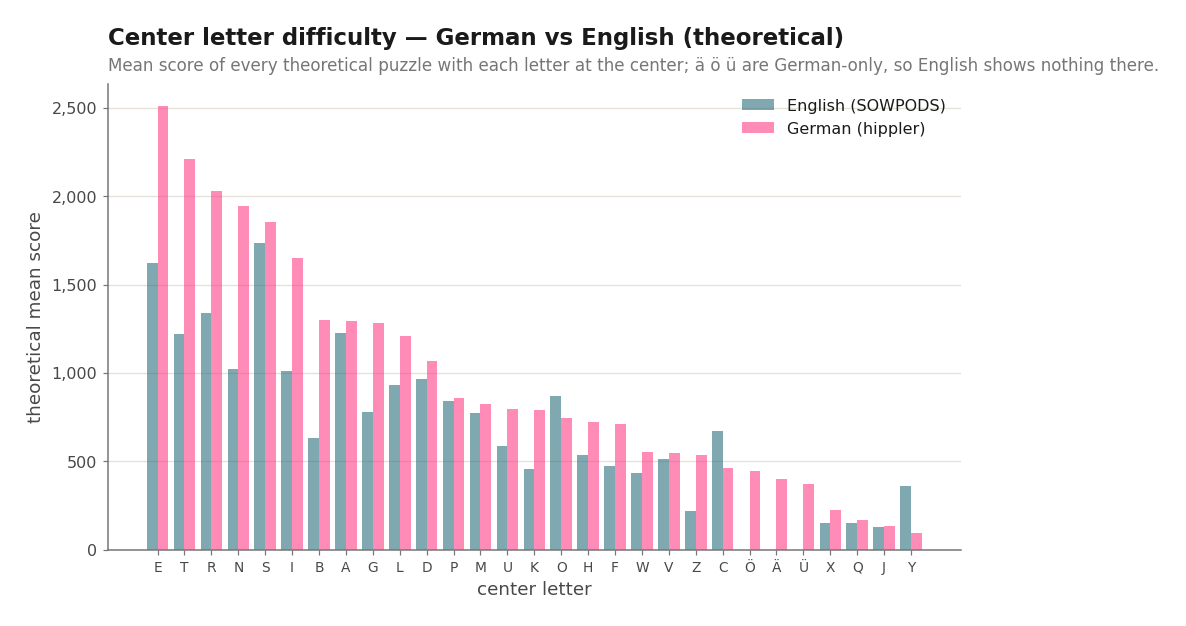

In [ ]:
de_by_center = defaultdict(list)
for sc, S, c, nw, npan in res_de["puzzles"]:
    de_by_center[bit_to_letter(c, bit_de)].append(sc)
de_mean = {ch.upper(): np.mean(v) for ch, v in de_by_center.items()}

# Combine the German alphabet (incl. ä ö ü) with the English one and order by German mean.
letters_all = sorted(set(de_mean) | set(th_mean), key=lambda k: -de_mean.get(k, 0))
x = np.arange(len(letters_all)); w = 0.4
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - w/2, [th_mean.get(l, 0) for l in letters_all], w, color=PRIMARY,   alpha=HIST_ALPHA, label="English (SOWPODS)")
ax.bar(x + w/2, [de_mean.get(l, 0) for l in letters_all], w, color=HIGHLIGHT, alpha=HIST_ALPHA, label="German (hippler)")
ax.set_xticks(x); ax.set_xticklabels(letters_all, fontsize=9)
ax.set_ylabel("theoretical mean score"); B.thousands(ax, "y")
ax.set_xlabel("center letter"); ax.legend()
B.title(ax, "Center letter difficulty — German vs English (theoretical)",
        "Mean score of every theoretical puzzle with each letter at the center; "
        "ä ö ü are German-only, so English shows nothing there.")
B.show(fig, title="centre letter german")

#### 6.3.2 Contains S vs does not — does the S effect carry over?

with-S: mean=1612   no-S: mean=1209   S lift factor: 1.33×
  wrote figures/17_s_rule_german.png


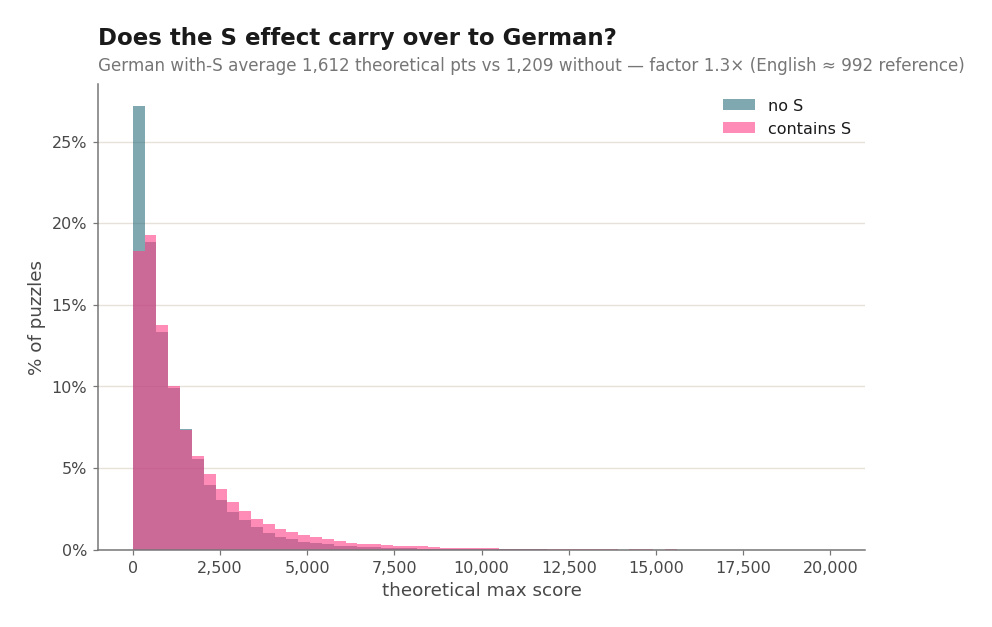

In [ ]:
sbit_de = 1 << bit_de["s"]
withs_d = np.array([p[0] for p in res_de["puzzles"] if p[1] & sbit_de])
nos_d   = np.array([p[0] for p in res_de["puzzles"] if not p[1] & sbit_de])
print(f"with-S: mean={withs_d.mean():.0f}   no-S: mean={nos_d.mean():.0f}   "
      f"S lift factor: {withs_d.mean()/nos_d.mean():.2f}×")

fig, ax = plt.subplots()
bins = np.linspace(0, 20000, 60)
w_nosd   = np.full(nos_d.shape,   100.0 / len(nos_d))
w_withsd = np.full(withs_d.shape, 100.0 / len(withs_d))
ax.hist(nos_d,   bins=bins, weights=w_nosd,   color=PRIMARY,   alpha=HIST_ALPHA, label="no S")
ax.hist(withs_d, bins=bins, weights=w_withsd, color=HIGHLIGHT, alpha=HIST_ALPHA, label="contains S")
ax.set_xlabel("theoretical max score"); ax.set_ylabel("% of puzzles")
B.thousands(ax, "x"); B.pct(ax, "y", decimals=0, xmax=100); ax.legend()
B.title(ax, "Does the S effect carry over to German?",
        f"German with-S average {withs_d.mean():,.0f} theoretical pts vs {nos_d.mean():,.0f} without — "
        f"factor {withs_d.mean()/nos_d.mean():.1f}× (English ≈ {scores_en[scores_en>0].mean():,.0f} reference)")
B.show(fig, title="s rule german")

---

*Source: [SOWPODS](https://github.com/jesstess/Scrabble) (English), [hippler/german-wordlist](https://github.com/hippler/german-wordlist) (German). Real NYT puzzles scraped from [sbsolver.com](https://www.sbsolver.com). Figures use the shared [rigter.ink style](https://github.com/fabianrigterink/rigter-ink/blob/main/notebooks/blogstyle.py).*